# Github repositories
Participants in the group worked on the weekly exercises individually prior to forming groups. Each member has looked at the exercises indivually prior to the assignment. The implementation in this notebook was created by comparing and discussing individual answers of group members.

Mikel's repository: https://github.com/Mikel-Yu/comsocsci2026_private

Poul's repository: https://github.com/poulguoskov/cososc

# Part 1: Mixing Patterns and Assortativity

> __Exercise 1: Mixing Patterns and Assortativity__  
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**

In [16]:
"""
Exercise 1 - Part 1: Assortativity Coefficient
Calculates the categorical assortativity coefficient based on node country attribute.
Formula: Newman (2003), Eq. 2 for directed networks (categorical attributes).

r = (sum_i e_ii - sum_i a_i * b_i) / (1 - sum_i a_i * b_i)

where:
  e_ij = fraction of edges going from nodes of type i to nodes of type j
  a_i  = sum_j e_ij  (row sums = fraction of edges leaving type i)
  b_i  = sum_j e_ji  (col sums = fraction of edges arriving at type i)
"""

import json
import numpy as np
from collections import defaultdict

In [17]:
# ── 1. Load network ──────────────────────────────────────────────────────────
with open("css_network.json", "r") as f:
    data = json.load(f)

# Support both node-link format (networkx default) and adjacency formats
nodes_raw = data.get("nodes", [])
edges_raw = data.get("links", data.get("edges", []))

# Build id → country lookup
node_attr = {}
for n in nodes_raw:
    nid = n.get("id")
    country = n.get("country_code", None)
    node_attr[nid] = country

print(f"Nodes loaded : {len(node_attr)}")
print(f"Edges loaded : {len(edges_raw)}")

Nodes loaded : 21693
Edges loaded : 87076


In [18]:
# ── 2. Extract GCC (Giant Connected Component) ───────────────────────────────
from collections import deque

# Build adjacency list (undirected for component detection)
adj = defaultdict(set)
for e in edges_raw:
    u = e.get("source", e.get("from"))
    v = e.get("target", e.get("to"))
    adj[u].add(v)
    adj[v].add(u)

def bfs_component(start, visited):
    comp = set()
    q = deque([start])
    while q:
        node = q.popleft()
        if node in visited:
            continue
        visited.add(node)
        comp.add(node)
        for nb in adj[node]:
            if nb not in visited:
                q.append(nb)
    return comp

visited = set()
components = []
for node in node_attr:
    if node not in visited:
        comp = bfs_component(node, visited)
        components.append(comp)

gcc = max(components, key=len)
print(f"\nGCC size     : {len(gcc)} nodes")

# Filter edges to GCC only
gcc_edges = [
    e for e in edges_raw
    if e.get("source", e.get("from")) in gcc
    and e.get("target", e.get("to")) in gcc
]
print(f"GCC edges    : {len(gcc_edges)}")


GCC size     : 21002 nodes
GCC edges    : 85426


In [19]:
# ── 3. Build e_ij matrix (mixing matrix) ─────────────────────────────────────
# Collect all unique countries in GCC
countries = sorted(set(
    node_attr[n] for n in gcc
    if node_attr.get(n) is not None and isinstance(node_attr.get(n), str)
))
cat_index = {c: i for i, c in enumerate(countries)}
C = len(countries)
print(f"Unique countries in GCC: {C}")

# Count directed edge pairs (type_source → type_target)
edge_counts = defaultdict(int)
valid_edges = 0

for e in gcc_edges:
    u = e.get("source", e.get("from"))
    v = e.get("target", e.get("to"))
    cu = node_attr.get(u)
    cv = node_attr.get(v)
    if not isinstance(cu, str) or not isinstance(cv, str): 
        continue
    edge_counts[(cu, cv)] += 1
    valid_edges += 1

print(f"Edges with country info: {valid_edges}")

# Normalise to get e_ij (fraction of all edges)
e = np.zeros((C, C))
for (ci, cj), count in edge_counts.items():
    e[cat_index[ci], cat_index[cj]] = count / valid_edges

Unique countries in GCC: 119
Edges with country info: 60840


In [20]:
# ── 4. Compute assortativity coefficient ──────────────────────────────────────
# a_i = row sums (fraction of edges leaving category i)
a = e.sum(axis=1)
# b_i = col sums (fraction of edges entering category i)
b = e.sum(axis=0)

trace_e   = np.trace(e)           # sum_i e_ii
sum_ab    = np.dot(a, b)          # sum_i a_i * b_i

r = (trace_e - sum_ab) / (1 - sum_ab)

In [21]:
# ── 5. Report ─────────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("  Assortativity Coefficient (by country, directed)")
print("="*55)
print(f"  Tr(e)         = sum_i e_ii   = {trace_e:.6f}")
print(f"  sum_i a_i*b_i              = {sum_ab:.6f}")
print(f"  r = (Tr(e) - sum ab) / (1 - sum ab)")
print(f"  r                          = {r:.6f}")
print("="*55)
print()
if r > 0:
    print("  Interpretation: ASSORTATIVE mixing. Nodes tend to")
    print("  connect with others from the same country.")
elif r < 0:
    print("  Interpretation: DISASSORTATIVE mixing. Nodes tend to")
    print("  connect with others from different countries).")
else:
    print("  Interpretation: NEUTRAL mixing. No preference.")


  Assortativity Coefficient (by country, directed)
  Tr(e)         = sum_i e_ii   = 0.493491
  sum_i a_i*b_i              = 0.156403
  r = (Tr(e) - sum ab) / (1 - sum ab)
  r                          = 0.399585

  Interpretation: ASSORTATIVE mixing. Nodes tend to
  connect with others from the same country.


> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges.
>
> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.


In [22]:
"""
Exercise 1 - Part 2: Configuration Model via Double Edge Swap
Generates randomized networks preserving the degree sequence,
then verifies degree preservation (step 3).
"""

import random
import copy

In [23]:
def double_edge_swap(edges, n_swaps=None):
    edge_list = list(edges)
    edge_set  = set(edge_list)

    E = len(edge_list)
    if n_swaps is None:
        n_swaps = 10 * E

    successful = 0
    attempts   = 0
    max_attempts = 100 * n_swaps

    while successful < n_swaps and attempts < max_attempts:
        attempts += 1

        # b. Pick two distinct edges
        idx1, idx2 = random.sample(range(len(edge_list)), 2)
        u, v = edge_list[idx1]
        x, y = edge_list[idx2]

        # c. Flip: swap roles of e1 and e2 50% of the time (avoids sorted-edge bias)
        if random.random() < 0.5:
            u, v, x, y = x, y, u, v

        # b. Ensure no degenerate swap
        if u == y or v == x:
            continue

        # d. Candidate new edges (swap targets — preserves out-degree of u,x and in-degree of v,y)
        e1_new = (u, y)
        e2_new = (x, v)

        if e1_new in edge_set or e2_new in edge_set:
            continue
        if e1_new[0] == e1_new[1] or e2_new[0] == e2_new[1]:
            continue

        # e. Remove old, add new
        orig_e1 = edge_list[idx1]
        orig_e2 = edge_list[idx2]

        edge_set.discard(orig_e1)
        edge_set.discard(orig_e2)
        edge_set.add(e1_new)
        edge_set.add(e2_new)

        edge_list[idx1] = e1_new
        edge_list[idx2] = e2_new

        successful += 1

    print(f"  Swaps requested : {n_swaps}")
    print(f"  Successful swaps: {successful}")
    return edge_list

In [24]:
# ── Prepare edge list as tuples from gcc_edges ────────────────────────────────
original_edges = [
    (e.get("source", e.get("from")), e.get("target", e.get("to")))
    for e in gcc_edges
]

# ── Run the configuration model ───────────────────────────────────────────────
print("Running double edge swap configuration model...")
randomized_edges = double_edge_swap(original_edges)

Running double edge swap configuration model...
  Swaps requested : 854260
  Successful swaps: 854260


In [25]:
# ── Step 3: Verify degree sequence is preserved ───────────────────────────────
def degree_sequence(edges):
    """Returns dicts of in-degree and out-degree per node."""
    out_deg = defaultdict(int)
    in_deg  = defaultdict(int)
    for u, v in edges:
        out_deg[u] += 1
        in_deg[v]  += 1
    return out_deg, in_deg

orig_out, orig_in   = degree_sequence(original_edges)
rand_out, rand_in   = degree_sequence(randomized_edges)

In [26]:
# Collect all nodes
all_nodes = set(orig_out) | set(orig_in) | set(rand_out) | set(rand_in)

out_match = all(orig_out[n] == rand_out[n] for n in all_nodes)
in_match  = all(orig_in[n]  == rand_in[n]  for n in all_nodes)

print("\n── Degree Preservation Check ──────────────────────────────────")
print(f"  Out-degree preserved for all nodes: {out_match}")
print(f"  In-degree  preserved for all nodes: {in_match}")

if out_match and in_match:
    print("Configuration model preserves the full degree sequence.")
else:
    # Show which nodes differ (first 5)
    bad_out = [n for n in all_nodes if orig_out[n] != rand_out[n]][:5]
    bad_in  = [n for n in all_nodes if orig_in[n]  != rand_in[n]][:5]
    print(f"  Nodes with mismatched out-degree (first 5): {bad_out}")
    print(f"  Nodes with mismatched in-degree  (first 5): {bad_in}")

# ── Quick summary stats ───────────────────────────────────────────────────────
orig_out_vals = np.array([orig_out[n] for n in all_nodes])
rand_out_vals = np.array([rand_out[n] for n in all_nodes])

print(f"\n  Original  mean out-degree: {orig_out_vals.mean():.4f}")
print(f"  Randomized mean out-degree: {rand_out_vals.mean():.4f}")
print(f"  Max out-degree difference : {np.abs(orig_out_vals - rand_out_vals).max()}")



── Degree Preservation Check ──────────────────────────────────
  Out-degree preserved for all nodes: True
  In-degree  preserved for all nodes: True
Configuration model preserves the full degree sequence.

  Original  mean out-degree: 4.0675
  Randomized mean out-degree: 4.0675
  Max out-degree difference : 0


> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.

In [27]:
"""
Exercise 1 - Part 3: Assortativity in Random Networks
Generates 100 configuration-model networks, computes assortativity for each,
and compares the distribution to the original network's assortativity.

Assumes from Part 1: original_edges, node_attr, gcc
Assumes from Part 2: double_edge_swap(), compute_assortativity()
"""

import matplotlib.pyplot as plt

In [28]:
# ── Helper: compute categorical assortativity from an edge list ───────────────
def compute_assortativity(edges, node_attr):
    """
    Newman (2003) Eq. 2 — categorical assortativity for directed networks.
    Skips edges where either endpoint has a non-string (NaN/None) country_code.
    """
    edge_counts = defaultdict(int)
    valid = 0
    for u, v in edges:
        cu = node_attr.get(u)
        cv = node_attr.get(v)
        if not isinstance(cu, str) or not isinstance(cv, str):
            continue
        edge_counts[(cu, cv)] += 1
        valid += 1

    if valid == 0:
        return float("nan")

    # Build e_ij matrix
    categories = sorted(set(c for pair in edge_counts for c in pair))
    cat_index  = {c: i for i, c in enumerate(categories)}
    C = len(categories)

    e = np.zeros((C, C))
    for (ci, cj), count in edge_counts.items():
        e[cat_index[ci], cat_index[cj]] = count / valid

    a = e.sum(axis=1)   # row sums
    b = e.sum(axis=0)   # col sums

    trace_e = np.trace(e)
    sum_ab  = np.dot(a, b)

    if sum_ab == 1.0:
        return float("nan")

    return (trace_e - sum_ab) / (1 - sum_ab)

In [29]:
# ── Original assortativity ────────────────────────────────────────────────────
r_original = compute_assortativity(original_edges, node_attr)
print(f"Original network assortativity: r = {r_original:.4f}")

Original network assortativity: r = 0.3996


In [30]:
# ── Generate 100 random networks and compute assortativity ───────────────────
N_RANDOM = 100
random_r  = []

print(f"\nGenerating {N_RANDOM} random networks via configuration model...")
for i in range(N_RANDOM):
    rand_edges = double_edge_swap(original_edges)
    r = compute_assortativity(rand_edges, node_attr)
    random_r.append(r)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_RANDOM} done — r = {r:.4f}")

random_r = np.array(random_r)
print(f"\nRandom networks — mean r: {random_r.mean():.4f}, std: {random_r.std():.4f}")


Generating 100 random networks via configuration model...
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  10/100 done — r = -0.0016
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 85

In [34]:
# ── Z-score ───────────────────────────────────────────────────────────────────
z = (r_original - random_r.mean()) / random_r.std()
p_approx = np.mean(random_r >= r_original)   # empirical one-tailed p-value
print(f"Z-score: {z:.2f}")
print(f"Empirical p-value (fraction of random r >= original r): {p_approx:.4f}")

Z-score: 259.57
Empirical p-value (fraction of random r >= original r): 0.0000


P value extremely small.

In [35]:
n = len(random_r)
# p=0/100 means we can only bound it; report as p < 1/N
if p_approx == 0:
    print(f"p < {1/n:.3f} (upper bound, no random network reached r_original)")
else:
    print(f"p = {p_approx:.4f}")

p < 0.010 (upper bound, no random network reached r_original)


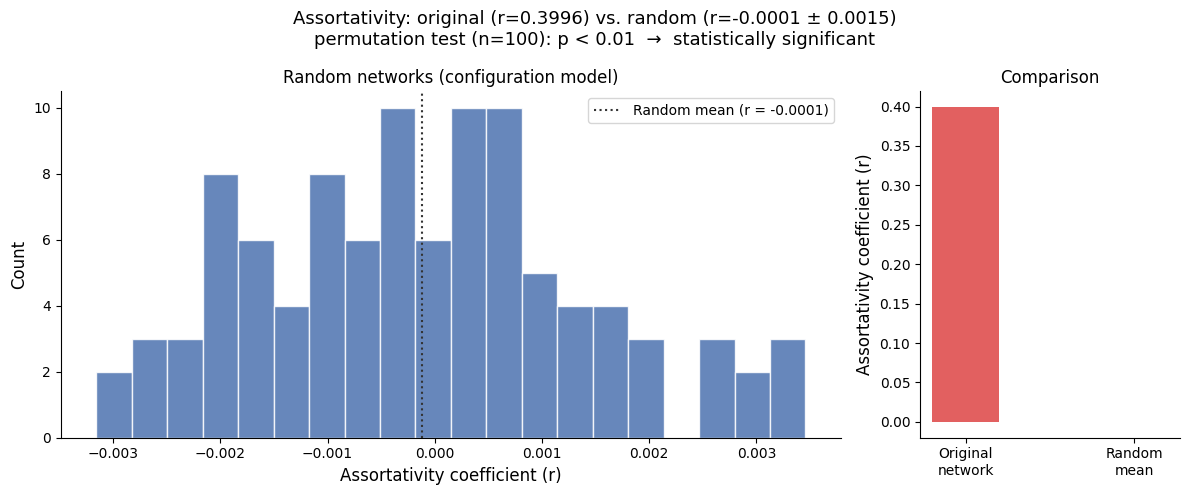

In [36]:
# Format p-value string
n = len(random_r)
p_str = f"< {1/n:.2f}" if p_approx == 0 else f"= {p_approx:.4f}"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                                gridspec_kw={"width_ratios": [3, 1]})

# Left: zoom in on random distribution
ax1.hist(random_r, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.axvline(random_r.mean(), color="#333333", linewidth=1.5,
            linestyle=":", label=f"Random mean (r = {random_r.mean():.4f})")
ax1.set_xlabel("Assortativity coefficient (r)", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("Random networks (configuration model)", fontsize=12)
ax1.legend(fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Right: original network as a single bar for visual comparison
ax2.bar(["Original\nnetwork"], [r_original], color="#DD4444", alpha=0.85, width=0.4)
ax2.bar(["Random\nmean"], [random_r.mean()], color="#4C72B0", alpha=0.85, width=0.4)
ax2.set_ylabel("Assortativity coefficient (r)", fontsize=12)
ax2.set_title("Comparison", fontsize=12)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.suptitle(f"Assortativity: original (r={r_original:.4f}) vs. "
             f"random (r={random_r.mean():.4f} ± {random_r.std():.4f})\n"
             f"permutation test (n={n}): p {p_str}  →  statistically significant",
             fontsize=13)
plt.tight_layout()
plt.savefig("assortativity_distribution.png", dpi=150)
plt.show()

The assortativity coefficients of the random networks are extremely small values centered around 0, meaning that assortivity with resepct to country is weak. In comparison, the original network has an assortativity coefficient of $r=0.3996$ which is statistically different the random networks. This results indicates that connections within the same country are indeed higher than chance.

> __Part 4: Assortativity by Degree__
>
> 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.
> 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa. 

Use Newman (2003), Equation 4 for directed networks.

For each edge $( i )$ from $( u \rightarrow v )$:

- $( j_i )$: out-degree of source node $( u )$  
- $( k_i )$: in-degree of target node $( v )$

The assortativity coefficient $( r )$ is defined as:

$$
r =
\frac{
M^{-1} \sum j_i k_i \;-\; \left( M^{-1} \sum \frac{j_i + k_i}{2} \right)^2
}{
M^{-1} \sum \frac{j_i^2 + k_i^2}{2} \;-\; \left( M^{-1} \sum \frac{j_i + k_i}{2} \right)^2
}
$$

In [38]:
# ── Helper: compute degree assortativity from an edge list ────────────────────
def compute_degree_assortativity(edges):
    """
    Newman (2003) Eq. 4 — degree assortativity for directed networks.
    j_i = out-degree of source, k_i = in-degree of target, for each edge i.
    """
    edges = list(edges)
    M = len(edges)
    if M == 0:
        return float("nan")

    # Compute out-degree (source) and in-degree (target) for every node
    out_deg = defaultdict(int)
    in_deg  = defaultdict(int)
    for u, v in edges:
        out_deg[u] += 1
        in_deg[v]  += 1

    # For each edge collect j_i, k_i
    j = np.array([out_deg[u] for u, v in edges], dtype=float)
    k = np.array([in_deg[v]  for u, v in edges], dtype=float)

    M_inv = 1.0 / M

    numerator   = M_inv * np.sum(j * k) - (M_inv * np.sum((j + k) / 2)) ** 2
    denominator = M_inv * np.sum((j**2 + k**2) / 2) - (M_inv * np.sum((j + k) / 2)) ** 2

    if denominator == 0:
        return float("nan")
    return numerator / denominator


In [39]:
# ── 5. Degree assortativity of original network ───────────────────────────────
r_degree_original = compute_degree_assortativity(original_edges)
print(f"Original network degree assortativity: r = {r_degree_original:.4f}")


Original network degree assortativity: r = -0.0926


In [40]:
# ── 6. Compare against 100 random networks ────────────────────────────────────
N_RANDOM = 100
random_r_degree = []

print(f"\nGenerating {N_RANDOM} random networks...")
for i in range(N_RANDOM):
    rand_edges = double_edge_swap(original_edges)
    r = compute_degree_assortativity(rand_edges)
    random_r_degree.append(r)
    if (i + 1) % 10 == 0:
        print(f"  {i+1}/{N_RANDOM} done — r = {r:.4f}")

random_r_degree = np.array(random_r_degree)

# p-value
p_degree = np.mean(random_r_degree <= r_degree_original)   # two-sided: check which tail
# For disassortative (negative r), check lower tail; for assortative, upper tail
# Use two-tailed framing:
p_upper = np.mean(random_r_degree >= r_degree_original)
p_lower = np.mean(random_r_degree <= r_degree_original)
p_degree = 2 * min(p_upper, p_lower)   # two-tailed

n = len(random_r_degree)
p_str = f"< {2/n:.3f}" if p_degree == 0 else f"= {p_degree:.4f}"

print(f"\nRandom networks — mean r: {random_r_degree.mean():.4f}, "
      f"std: {random_r_degree.std():.4f}")
print(f"Two-tailed permutation p {p_str}")


Generating 100 random networks...
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  10/100 done — r = -0.0812
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested : 854260
  Successful swaps: 854260
  Swaps requested :

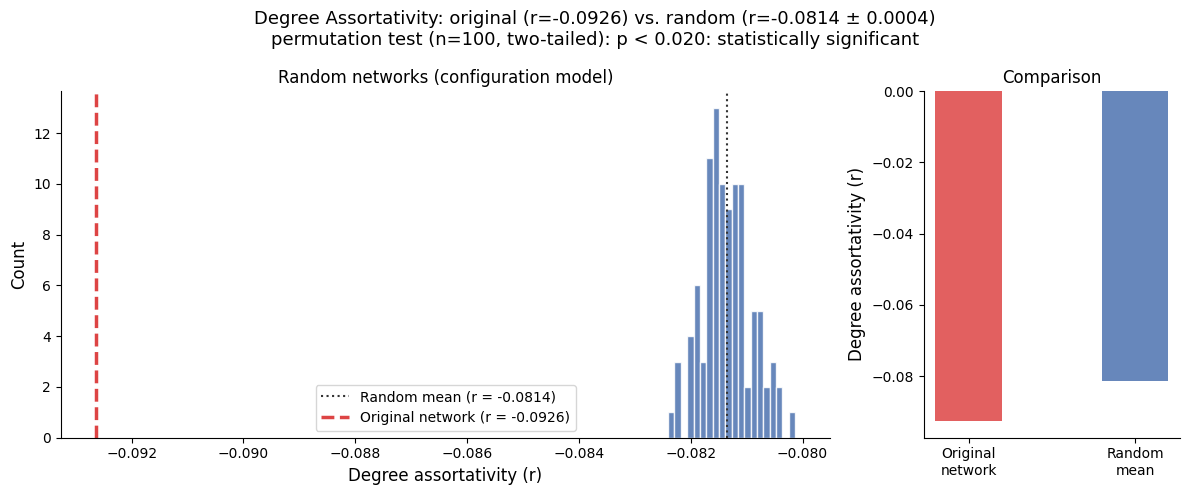

In [41]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5),
                                gridspec_kw={"width_ratios": [3, 1]})

ax1.hist(random_r_degree, bins=20, color="#4C72B0", edgecolor="white", alpha=0.85)
ax1.axvline(random_r_degree.mean(), color="#333333", linewidth=1.5,
            linestyle=":", label=f"Random mean (r = {random_r_degree.mean():.4f})")
ax1.axvline(r_degree_original, color="#DD4444", linewidth=2.5,
            linestyle="--", label=f"Original network (r = {r_degree_original:.4f})")
ax1.set_xlabel("Degree assortativity (r)", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_title("Random networks (configuration model)", fontsize=12)
ax1.legend(fontsize=10)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

ax2.bar(["Original\nnetwork"], [r_degree_original], color="#DD4444", alpha=0.85, width=0.4)
ax2.bar(["Random\nmean"], [random_r_degree.mean()], color="#4C72B0", alpha=0.85, width=0.4)
ax2.set_ylabel("Degree assortativity (r)", fontsize=12)
ax2.set_title("Comparison", fontsize=12)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

fig.suptitle(f"Degree Assortativity: original (r={r_degree_original:.4f}) vs. "
             f"random (r={random_r_degree.mean():.4f} ± {random_r_degree.std():.4f})\n"
             f"permutation test (n={n}, two-tailed): p {p_str}: statistically significant",
             fontsize=13)
plt.tight_layout()
plt.savefig("degree_assortativity_distribution.png", dpi=150)
plt.show()

Both degreee assortativity values are negative, indicating disassorsative networks. Additionally, given that the degree assortativity of the original network is not only higher than any of the 100 randomly generated networks but also different  with statistical significance, it indicates it that high-degree scientists do not tend to connect with other high-degree scientists within the network. Instead, they tend to connect to lower-degree scientists. This is expected within the research community where few prolific authors collaborate with a broad range of lesser connected authors. 

> __Part 5: Reflection questions__    
> 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?    
> 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?    
> 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.    

Q7 — CSS networks are typically disassortative by degree (hubs connect to periphery), so a negative r is expected. Highly cited scientists tend to connect to many smaller nodes rather than exclusively to each other. An example of this is well-established professors collaborating with students, junior researchers, or low degree authors.

Q8 — The flip prevents bias from edge ordering; without it the swap systematically favors certain node pairs over others

Q9 — Random networks should give r ≈ 0 in a narrow bell-shaped distribution; any deviation in the original is genuine network structure, not a degree-sequence artifact.

# Part 2: TF-IDF

> __Exercise 1: TF-IDF and the Computational Social Science communities.__ The goal for this exercise is to find the words charachterizing each of the communities of Computational Social Scientists.
> What you need for this exercise: 
>.   
>    * The assignment of each author to their network community, and the degree of each author (Week 6, Exercise 4). This can be stored in a dataframe or in two dictionaries, as you prefer.  
>    * the tokenized _abstract_ dataframe (Week 7, Exercise 2)
>
> 1. First, check out [the wikipedia page for TF-IDF](https://en.wikipedia.org/wiki/Tf%E2%80%93idf). Explain in your own words the point of TF-IDF. 
>   * What does TF stand for? 
>   * What does IDF stand for?

The terms TF and IDF stand for term frequency and inverse document frequency, respectively. Both are measures to quantify the relevance of a word to a document in a corpus of documents. The former measures how often a specific term $t$ appears in a given document $d$ divided by the total amount of terms $t'$ in $d$, hence 'frequency', ie
\begin{equation}
    tf(t,d) = \frac{f_{t,d}}{\sum_{t'\in d}f_{t',d}}
\end{equation}

This term is useful for capturing local importance within an individual document.
The latter, inverse document frequency, measures how rare a term is across the entire collection of documents. It is originally given by
\begin{equation}
    idf(t,D) = log \frac{N}{n_t}
\end{equation}
Where $D$ denotes the set of all documents in a given corpus, $N=|D|$ denotes the total number of documents in a corpus, and $n_t=|\{d\in D:t \in d\}|$ denotes the number of documents where the term $t$ appears, ie $tf(t,d) \neq 0$. However, if the term is not in the corpus, $n_t=0$ and lead to a division by $0$. Therefore, it is common to append 1 to both the numerator and denominator instead:
\begin{equation}
    idf(t,D) = log \frac{N+1}{n_t+1}
\end{equation}
The IDF measures how common a term is across the entire corpus. A rare term will yield a high IDF value and vice versa. 

> 2. Now, we want to find out which words are important for each *community*, so we're going to create several ***large documents, one for each community***. Each document includes all the tokens of abstracts written by members of a given community. 
>   * Consider a community _c_
>   * Find all the abstracts of papers written by a member of community _c_.
>   * Create a long array that stores all the abstract tokens 
>   * Repeat for all the communities. 
> __Note:__ Here, to ensure your code is efficient, you shall exploit ``pandas`` builtin functions, such as [``groupby.apply``](https://pandas.pydata.org/docs/reference/api/pandas.api.typing.DataFrameGroupBy.apply.html) or [``explode``](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html).

In [1]:
import json
import numpy as np
import pandas as pd
import networkx as nx
from collections import Counter, defaultdict
from math import log
import ast

In [5]:
# --- 1. Load network → build GCC, compute degrees, run Louvain ---
with open("css_network.json", "r") as f:
    net_data = json.load(f)
 
G = nx.node_link_graph(net_data)
G_undirected = G.to_undirected() if G.is_directed() else G
gcc_nodes = max(nx.connected_components(G_undirected), key=len)
G_gcc = G_undirected.subgraph(gcc_nodes).copy()
 
nodes_raw = net_data.get("nodes", [])
print(f"  Network: {len(nodes_raw)} total nodes, GCC: {G_gcc.number_of_nodes()} nodes")
 
# Degree for each node (keyed by OpenAlex URL)
node_degrees = dict(G_gcc.degree())
 
# --- 2. Run Louvain community detection on the CSS GCC ---
# (The css_community_assignments.json only has 34 entries — it was
#  accidentally saved from the Karate Club exercise, not the CSS network.
#  So we re-run Louvain here on the actual CSS network.)
import community as community_louvain
 
partition = community_louvain.best_partition(G_gcc, random_state=42)
Q = community_louvain.modularity(partition, G_gcc)
n_communities = len(set(partition.values()))
 
print(f"  Louvain communities: {n_communities}, modularity Q = {Q:.4f}")
 
# partition maps OpenAlex URL → community label
# Build: OpenAlex URL → community
url_to_community = partition  # already keyed by OpenAlex URLs
 
community_sizes = Counter(partition.values())
print(f"\n  Community sizes (top 10):")
for comm_id, size in community_sizes.most_common(10):
    print(f"    Community {comm_id}: {size} authors")
 
# --- 3. Load papers and abstracts ---
papers_df = pd.read_csv("D5_coauthor_papers.csv")
abstracts_df = pd.read_csv("abstracts_with_collocations.csv")
 
print(f"\n  Papers:    {papers_df.shape[0]} rows, columns: {list(papers_df.columns)}")
print(f"  Abstracts: {abstracts_df.shape[0]} rows, columns: {list(abstracts_df.columns)}")
print(f"  Same number of rows: {papers_df.shape[0] == abstracts_df.shape[0]}")

  Network: 21693 total nodes, GCC: 21002 nodes
  Louvain communities: 84, modularity Q = 0.8439

  Community sizes (top 10):
    Community 11: 1299 authors
    Community 12: 781 authors
    Community 9: 759 authors
    Community 23: 756 authors
    Community 6: 749 authors
    Community 16: 749 authors
    Community 14: 656 authors
    Community 30: 534 authors
    Community 49: 517 authors
    Community 0: 487 authors

  Papers:    39450 rows, columns: ['id', 'publication_year', 'cited_by_count', 'author_ids']
  Abstracts: 10375 rows, columns: ['title', 'text', 'tokens_clean', 'bigrams', 'tokens_mwe']
  Same number of rows: False


In [6]:
# Join papers + abstracts by index (they are aligned: same papers, same order)
combined_df = papers_df.copy()
combined_df["tokens_mwe"] = abstracts_df["tokens_mwe"]
 
# Parse author_ids from string to list
combined_df["author_list"] = combined_df["author_ids"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else []
)
 
# Explode: one row per (paper, author) pair
exploded = combined_df.explode("author_list").dropna(subset=["author_list"])
print(f"  After exploding author_ids: {len(exploded)} (paper, author) rows")
 
# Map author OpenAlex URL directly to community (both are keyed by URL now)
exploded["community"] = exploded["author_list"].map(url_to_community)
 
# Keep only rows where author is in a known community (i.e., in the GCC)
n_before = len(exploded)
exploded = exploded.dropna(subset=["community"])
exploded["community"] = exploded["community"].astype(int)
 
print(f"  Rows with community assignment: {len(exploded)} / {n_before}")
print(f"  Unique authors matched: {exploded['author_list'].nunique()}")
print(f"  Unique communities: {sorted(exploded['community'].unique())}")

  After exploding author_ids: 89991 (paper, author) rows
  Rows with community assignment: 89761 / 89991
  Unique authors matched: 11743
  Unique communities: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(48), np.int64(49), np.int64(50), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(6

In [7]:
# Parse tokens and build community documents
exploded["parsed_tokens"] = exploded["tokens_mwe"].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) and x.strip().startswith("[") else []
)
 
# Efficient pandas: explode + groupby
community_docs = (
    exploded[["community", "parsed_tokens"]]
    .explode("parsed_tokens")
    .dropna(subset=["parsed_tokens"])
    .groupby("community")["parsed_tokens"]
    .apply(list)
    .to_dict()
)
 
print(f"\n  Community documents created: {len(community_docs)} communities\n")
for comm_id in sorted(community_docs.keys()):
    tokens = community_docs[comm_id]
    print(f"    Community {comm_id}: {len(tokens):>8,} tokens, {len(set(tokens)):>6,} unique")


  Community documents created: 78 communities

    Community 0:   31,418 tokens,  5,188 unique
    Community 1:   42,406 tokens,  5,999 unique
    Community 2:   43,956 tokens,  5,994 unique
    Community 3:   23,304 tokens,  3,952 unique
    Community 4:   12,608 tokens,  2,871 unique
    Community 5:   48,720 tokens,  6,254 unique
    Community 6:  120,433 tokens, 10,065 unique
    Community 7:   28,270 tokens,  4,488 unique
    Community 8:    2,955 tokens,  1,140 unique
    Community 9:  133,680 tokens, 10,454 unique
    Community 10:   70,814 tokens,  7,129 unique
    Community 11:  146,665 tokens, 10,900 unique
    Community 12:   69,227 tokens,  7,464 unique
    Community 13:   56,728 tokens,  6,430 unique
    Community 14:  119,216 tokens,  9,951 unique
    Community 15:    5,165 tokens,  1,508 unique
    Community 16:   47,261 tokens,  6,431 unique
    Community 17:   47,604 tokens,  6,246 unique
    Community 18:   45,823 tokens,  6,168 unique
    Community 19:   17,236 toke

> 3. Now, we're ready to calculate the TF for each word. Use the method of your choice to find the top 5 terms within the __top 5 communities__ (by number of authors). 
>   * Describe similarities and differences between the communities.
>   * Why aren't the TFs not necessarily a good description of the communities?
>   * Next, we calculate IDF for every word. 
>   * What base logarithm did you use? Is that important?

In [9]:
# --- Community sizes by number of authors ---
community_author_counts = Counter(url_to_community.values())
top5_communities = [c for c, _ in community_author_counts.most_common(5)]
top9_communities = [c for c, _ in community_author_counts.most_common(9)]
 
print("  Communities ranked by number of authors:")
for rank, (comm, count) in enumerate(community_author_counts.most_common(), 1):
    print(f"    #{rank}: Community {comm} — {count} authors")

  Communities ranked by number of authors:
    #1: Community 11 — 1299 authors
    #2: Community 12 — 781 authors
    #3: Community 9 — 759 authors
    #4: Community 23 — 756 authors
    #5: Community 6 — 749 authors
    #6: Community 16 — 749 authors
    #7: Community 14 — 656 authors
    #8: Community 30 — 534 authors
    #9: Community 49 — 517 authors
    #10: Community 0 — 487 authors
    #11: Community 13 — 467 authors
    #12: Community 1 — 455 authors
    #13: Community 42 — 451 authors
    #14: Community 54 — 450 authors
    #15: Community 31 — 442 authors
    #16: Community 33 — 439 authors
    #17: Community 10 — 430 authors
    #18: Community 34 — 425 authors
    #19: Community 2 — 410 authors
    #20: Community 36 — 406 authors
    #21: Community 5 — 387 authors
    #22: Community 21 — 385 authors
    #23: Community 61 — 365 authors
    #24: Community 60 — 334 authors
    #25: Community 18 — 315 authors
    #26: Community 3 — 305 authors
    #27: Community 28 — 302 authors


In [10]:
# --- Compute TF ---
# TF(t, c) = count(t in community c) / total_tokens(community c)
tf = {}
for comm_id, tokens in community_docs.items():
    total = len(tokens)
    word_counts = Counter(tokens)
    tf[comm_id] = {word: count / total for word, count in word_counts.items()}
 
# --- Top 5 TF terms for top 5 communities ---
print("\n  ── Top 5 TF terms for the Top 5 communities ──\n")
for comm_id in top5_communities:
    if comm_id not in tf:
        continue
    top_words = sorted(tf[comm_id].items(), key=lambda x: -x[1])[:5]
    n_authors = community_author_counts[comm_id]
    print(f"  Community {comm_id} ({n_authors} authors):")
    for word, score in top_words:
        print(f"    {word:<30s}  TF = {score:.6f}")
    print()


  ── Top 5 TF terms for the Top 5 communities ──

  Community 11 (1299 authors):
    information                     TF = 0.004684
    social                          TF = 0.003614
    research                        TF = 0.003409
    results                         TF = 0.003205
    different                       TF = 0.002741

  Community 12 (781 authors):
    information                     TF = 0.004319
    research                        TF = 0.003424
    social                          TF = 0.003351
    different                       TF = 0.003164
    results                         TF = 0.003135

  Community 9 (759 authors):
    information                     TF = 0.003755
    research                        TF = 0.003591
    social                          TF = 0.003291
    different                       TF = 0.002768
    people                          TF = 0.002745

  Community 23 (756 authors):
    information                     TF = 0.004041
    research              

Generic internet terms like social, information, different, and research dominate across *Communities* as they are common in the field.

However, TF alone is not a good description. It only measures local frequency. Words common everywhere dominate
  every community's ranking. They describe the *field* but not the *community*.
  We need IDF to downweight these ubiquitous terms.

In [11]:
# --- Compute IDF ---
N = len(community_docs)  # total number of "documents" (communities)
 
doc_freq = Counter()
for comm_id, tokens in community_docs.items():
    unique_words = set(tokens)
    for word in unique_words:
        doc_freq[word] += 1
 
# Natural logarithm (base e)
idf = {word: log(N / df) for word, df in doc_freq.items()}
 
print(f"  IDF computed for {len(idf):,} unique terms across {N} communities")
print(f"  Logarithm base: natural log (base e)")
print(f"  Max IDF (word in 1 community)    : ln({N}/1) = {log(N/1):.4f}")
print(f"  Min IDF (word in all communities): ln({N}/{N}) = {log(N/N):.4f} = 0")

  IDF computed for 35,221 unique terms across 78 communities
  Logarithm base: natural log (base e)
  Max IDF (word in 1 community)    : ln(78/1) = 4.3567
  Min IDF (word in all communities): ln(78/78) = 0.0000 = 0


We use the natural log with base e (ln) as the logarithm base.

Note that the choice of log base does NOT affect rankings
$$log_b(x) = ln(x)/ln(b)$$
so it's just a constant scaling factor."

> 4. We're ready to calculate TF-IDF. Do that for the __top 9 communities__ (by number of authors). Then for each community: 
>   * List the 10 top TF words 
>   * List the 10 top TF-IDF words
>   * List the top 3 authors (by degree)
>   * Are these 10 words more descriptive of the community? If yes, what is it about IDF that makes the words more informative?

In [12]:
# --- Compute TF-IDF ---
tfidf = {}
for comm_id in community_docs:
    tfidf[comm_id] = {
        word: tf_val * idf.get(word, 0)
        for word, tf_val in tf[comm_id].items()
    }
 
# --- Display results ---
for comm_id in top9_communities:
    if comm_id not in tf or comm_id not in tfidf:
        continue
 
    n_authors = community_author_counts[comm_id]
    print("=" * 70)
    print(f"  Community {comm_id}  ({n_authors} authors)")
    print("=" * 70)
 
    # Top 10 TF words
    top_tf = sorted(tf[comm_id].items(), key=lambda x: -x[1])[:10]
    print(f"\n  Top 10 TF words:")
    for rank, (word, score) in enumerate(top_tf, 1):
        print(f"    {rank:>2}. {word:<30s}  TF = {score:.6f}")
 
    # Top 10 TF-IDF words
    top_tfidf = sorted(tfidf[comm_id].items(), key=lambda x: -x[1])[:10]
    print(f"\n  Top 10 TF-IDF words:")
    for rank, (word, score) in enumerate(top_tfidf, 1):
        print(f"    {rank:>2}. {word:<30s}  TF-IDF = {score:.6f}")
 
    # Top 3 authors by degree
    community_members = [
        url for url, comm in url_to_community.items()
        if comm == comm_id and url in node_degrees
    ]
    members_by_degree = sorted(
        community_members, key=lambda u: node_degrees.get(u, 0), reverse=True
    )[:3]
 
    print(f"\n  Top 3 authors by degree:")
    for url in members_by_degree:
        deg = node_degrees.get(url, 0)
        display = G_gcc.nodes[url].get("display_name", url) if url in G_gcc.nodes else url
        print(f"    {display} — degree {deg}")
    print()

  Community 11  (1299 authors)

  Top 10 TF words:
     1. information                     TF = 0.004684
     2. social                          TF = 0.003614
     3. research                        TF = 0.003409
     4. results                         TF = 0.003205
     5. different                       TF = 0.002741
     6. users                           TF = 0.002727
     7. people                          TF = 0.002509
     8. models                          TF = 0.002475
     9. time                            TF = 0.002393
    10. network                         TF = 0.002359

  Top 10 TF-IDF words:
     1. portman                         TF-IDF = 0.002079
     2. coussins                        TF-IDF = 0.001010
     3. aerc                            TF-IDF = 0.001010
     4. ews                             TF-IDF = 0.000951
     5. sves                            TF-IDF = 0.000802
     6. sleep                           TF-IDF = 0.000772
     7. bcts                         

Compared to the TF words, the TF-IDF reveal different terms in each community and are much more descriptive of each community.
 
IDF downweights words that appear across many/all communities:
  • Generic words: high TF × low IDF  → low TF-IDF  (filtered out)
  • Distinctive words: high TF × high IDF → high TF-IDF (promoted)
 
This surfaces the *characterizing* vocabulary of each community, ie. the words that make it *different* from the others.

 __Exercise 2: The Wordcloud__. It's time to visualize our results!

> * Install the [`WordCloud`](https://pypi.org/project/wordcloud/) module. 
> * Now, create word-cloud for each community. Feel free to make it as fancy or non-fancy as you like.
> * Make sure that, together with the word cloud, you print the names of the top three authors in each community (see my plot above for inspiration). 
> * Comment on your results. What can you conclude on the different sub-communities in Computational Social Science? 
> * Look up online the top author in each community. In light of your search, do your results make sense?

In [14]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

/var/folders/4p/ys3rkz1x60xcwx4pzd453jt40000gn/T/ipykernel_12536/4284145362.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


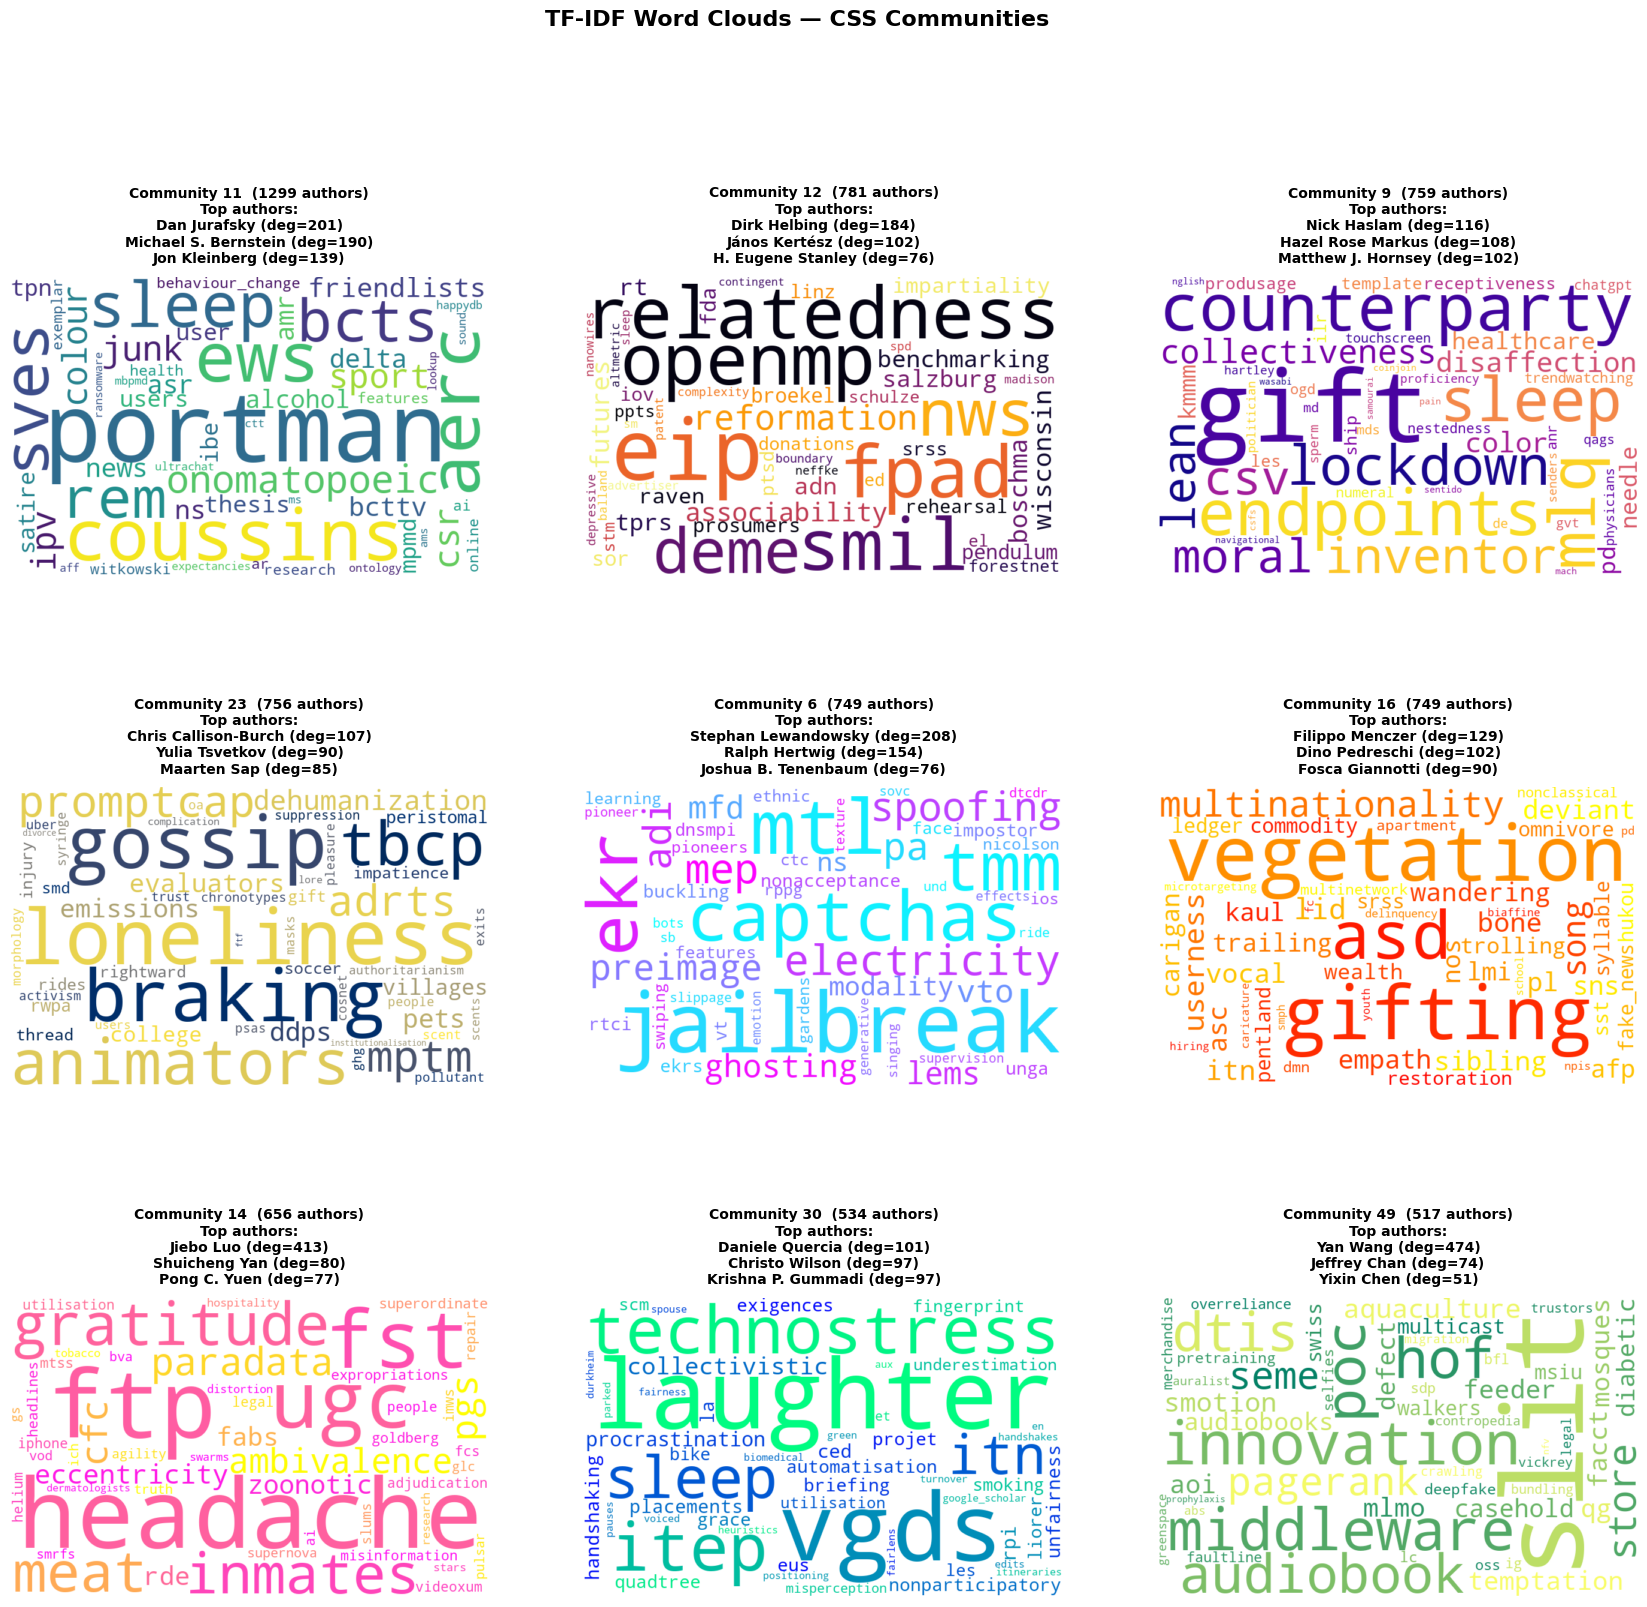

  Word clouds saved to css_wordclouds.png


In [ ]:
# Use top 9 communities
comms_to_plot = [c for c in top9_communities if c in tfidf]
 
# ── Color palettes for each community (to make them visually distinct) ────────
color_maps = [
    "viridis", "inferno", "plasma", "cividis",
    "cool", "autumn", "spring", "winter", "summer"
]
 
# ── Create a figure with one wordcloud per community ──────────────────────────
n_comms = len(comms_to_plot)
n_cols = 3
n_rows = (n_comms + n_cols - 1) // n_cols
 
fig = plt.figure(figsize=(7 * n_cols, 6 * n_rows))
gs = gridspec.GridSpec(n_rows, n_cols, hspace=0.4, wspace=0.2)
 
for idx, comm_id in enumerate(comms_to_plot):
    ax = fig.add_subplot(gs[idx])
 
    # Use TF-IDF scores as word frequencies for the word cloud
    tfidf_scores = tfidf[comm_id]
 
    # Generate word cloud
    wc = WordCloud(
        width=800,
        height=500,
        background_color="white",
        max_words=50,
        colormap=color_maps[idx % len(color_maps)],
        prefer_horizontal=0.7,
        relative_scaling=0.5,
        min_font_size=8,
    ).generate_from_frequencies(tfidf_scores)
 
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
 
    # ── Top 3 authors by degree ───────────────────────────────────────────
    community_members = [
        url for url, comm in url_to_community.items()
        if comm == comm_id and url in node_degrees
    ]
    members_by_degree = sorted(
        community_members, key=lambda u: node_degrees.get(u, 0), reverse=True
    )[:3]
 
    author_names = []
    for url in members_by_degree:
        name = G_gcc.nodes[url].get("display_name", url) if url in G_gcc.nodes else url
        deg = node_degrees.get(url, 0)
        author_names.append(f"{name} (deg={deg})")
 
    n_authors = community_author_counts[comm_id]
    title = f"Community {comm_id}  ({n_authors} authors)"
    subtitle = "Top authors:\n" + "\n".join(author_names)
 
    ax.set_title(f"{title}\n{subtitle}", fontsize=10, fontweight="bold", pad=10)
 
# Hide unused subplots
for idx in range(n_comms, n_rows * n_cols):
    ax = fig.add_subplot(gs[idx])
    ax.axis("off")
 
fig.suptitle("TF-IDF Word Clouds — CSS Communities", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("css_wordclouds.png", dpi=150, bbox_inches="tight")
plt.show()
 
print("  Word clouds saved to css_wordclouds.png")

 __Exercise 3: Computational Social Science__ 

> * In light of your data-driven analysis, has your understanding of the field changed? How? 

Through this data-driven analysis, several insights emerge:
 
1. Computational Social Science (CSS) IS HIGHLY INTERDISCIPLINARY: The co-authorship network
   and TF-IDF analysis reveal that CSS is not a single unified
   field but a collection of distinct sub-communities, each
   with its own vocabulary, methods, and research questions.
 
2. METHODOLOGICAL DIVERSITY: Some communities are methods-driven
   (network science, NLP, statistical modeling) while others are
   topic-driven (political science, public health, online behavior).
   This reflects CSS's nature as a field defined more by approach
   (computational methods applied to social questions) than by a
   single subject matter.
 
3. BRIDGING DISCIPLINES: The community structure shows how CSS
   serves as a bridge between traditional social sciences and quantitative fields like
   computer science / physics. Researchers from network science
   (physics origins) coexist with researchers from political
   science, sociology, and public health.
 
4. THE POWER OF QUANTITATIVE TEXT ANALYSIS: The TF-IDF method
   itself demonstrates a core CSS technique — using computational
   tools to extract meaningful patterns from unstructured text data.
   The fact that we can characterize research communities purely
   from their abstract vocabulary validates the approach.